In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_ameda = pd.read_pickle('/srv/scratch/z5297792/Chapter2/SEACOFS_26yr_Eddy_Dataset/Eddy_Data/df_eddies_processed_1462_10650.pkl')


In [2]:
sample_eddies_old = [100, 627, 1269, 2609, 34, 281, 2334, 3126]


In [3]:
def match_old_eddies(
    sample_eddies_old,
    df_eddies_old,
    df_eddies,
    min_overlap_frac=0.5,
    max_mean_dist=np.inf,
    plot=True,
):
    matches = []

    for eddy_old in sample_eddies_old:

        old = (
            df_eddies_old.loc[df_eddies_old.Eddy == eddy_old, ['Day', 'xc', 'yc']]
            .drop_duplicates('Day')
            .sort_values('Day')
        )

        old_days = set(old.Day)
        n_old = len(old)

        candidates = df_eddies.loc[df_eddies.Day.isin(old_days), 'Eddy'].unique()

        scores = []

        for eddy_new in candidates:

            new = (
                df_eddies.loc[df_eddies.Eddy == eddy_new, ['Day', 'xc', 'yc']]
                .drop_duplicates('Day')
                .sort_values('Day')
            )

            m = old.merge(new, on='Day', suffixes=('_old', '_new'))

            n_overlap = len(m)
            overlap_frac = n_overlap / n_old if n_old else 0

            if overlap_frac < min_overlap_frac:
                continue

            d = np.hypot(m.xc_new - m.xc_old, m.yc_new - m.yc_old)
            mean_dist = d.mean()

            if mean_dist > max_mean_dist:
                continue

            score = mean_dist / overlap_frac

            scores.append({
                'eddy_old': eddy_old,
                'eddy_new': eddy_new,
                'score': score,
                'mean_dist': mean_dist,
                'median_dist': d.median(),
                'max_dist': d.max(),
                'n_overlap': n_overlap,
                'n_old': n_old,
                'overlap_frac': overlap_frac,
            })

        if len(scores) == 0:
            matches.append({
                'eddy_old': eddy_old,
                'eddy_new': np.nan,
                'score': np.inf,
                'mean_dist': np.nan,
                'median_dist': np.nan,
                'max_dist': np.nan,
                'n_overlap': 0,
                'n_old': n_old,
                'overlap_frac': 0,
            })
            print(eddy_old, '->', np.nan)
            continue

        best = min(scores, key=lambda x: x['score'])
        matches.append(best)

        print(f"{eddy_old} -> {best['eddy_new']} "
              f"(overlap={best['overlap_frac']:.2f}, mean_dist={best['mean_dist']:.2f})")

        if plot:
            new = df_eddies.loc[df_eddies.Eddy == best['eddy_new']].sort_values('Day')

            plt.figure()
            plt.plot(old.xc, old.yc, label=f'old {eddy_old}')
            plt.plot(new.xc, new.yc, label=f'new {best["eddy_new"]}')
            plt.axis('equal')
            plt.legend()

    return pd.DataFrame(matches)
    

100 -> 159 (overlap=1.00, mean_dist=2.23)
627 -> 918 (overlap=1.00, mean_dist=0.26)
1269 -> 1833 (overlap=0.97, mean_dist=2.08)
2609 -> 3812 (overlap=1.00, mean_dist=0.62)
34 -> 20 (overlap=1.00, mean_dist=3.12)
281 -> 400 (overlap=1.00, mean_dist=8.33)
2334 -> 3412 (overlap=1.00, mean_dist=0.30)
3126 -> nan


,eddy_old,eddy_new,score,mean_dist,median_dist,max_dist,n_overlap,n_old,overlap_frac
0,100,159.0,2.230173,2.230173,1.448642,9.688525,23,23,1.000000
1,627,918.0,0.261864,0.261864,0.198451,0.675261,27,27,1.000000
2,1269,1833.0,2.141146,2.078171,1.388551,13.665879,33,34,0.970588
3,2609,3812.0,0.624855,0.624855,0.542597,1.460160,27,27,1.000000
4,34,20.0,3.123766,3.123766,0.529201,54.603860,106,106,1.000000
5,281,400.0,8.333378,8.333378,0.818734,54.782414,24,24,1.000000
6,2334,3412.0,0.297371,0.297371,0.254050,0.737518,27,27,1.000000
7,3126,NaN,inf,NaN,NaN,NaN,0,0,0.000000


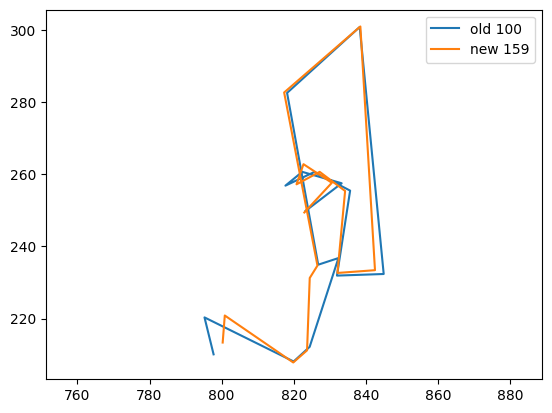

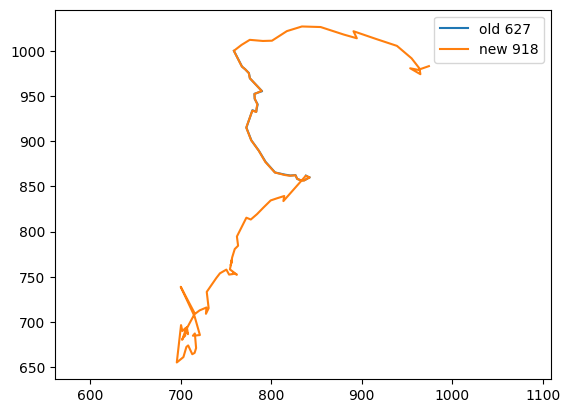

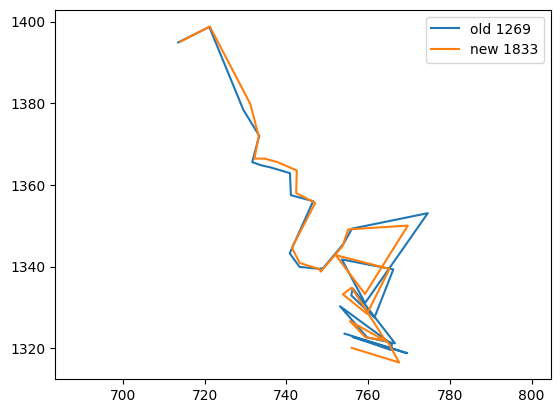

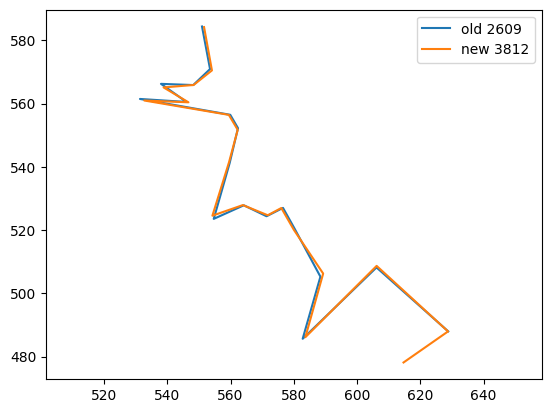

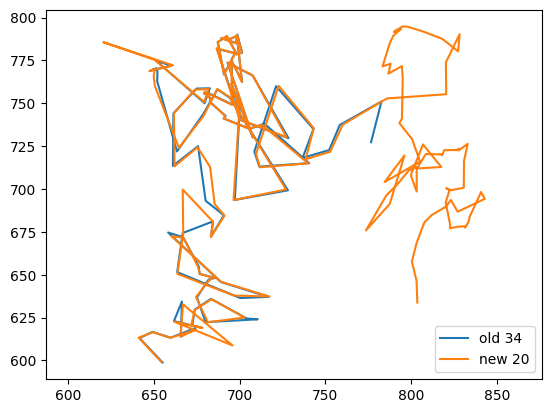

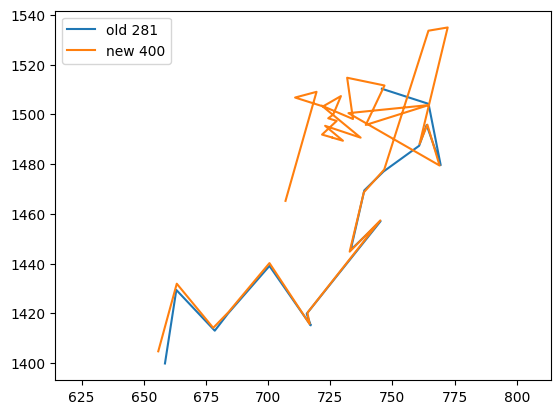

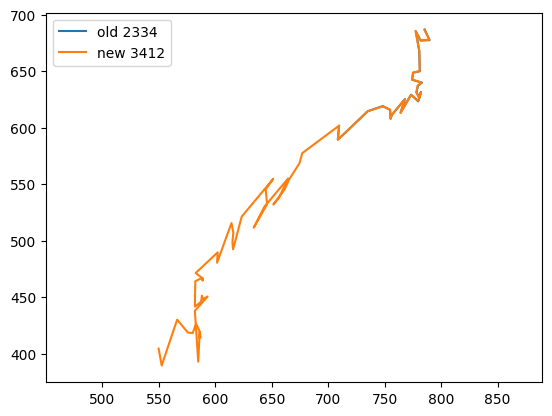

In [4]:
df_matches = match_old_eddies(
    sample_eddies_old,
    df_ameda,
    df_eddies,
    min_overlap_frac=0.6,
    max_mean_dist=30,
)
df_matches


In [5]:
pd.DataFrame({'old': [100, 627, 1269, 2609, 34, 281, 2334, 3126],
              'new': df_matches.eddy_new})


,old,new
0,100,159.0
1,627,918.0
2,1269,1833.0
3,2609,3812.0
4,34,20.0
5,281,400.0
6,2334,3412.0
7,3126,NaN


In [7]:
list(df_matches.eddy_new)

[159.0, 918.0, 1833.0, 3812.0, 20.0, 400.0, 3412.0, nan]